In [ ]:
# This is the class of the Companies Information like rating, name and other things

# ============================================================================================================================

# ================================== || Class of Company Information || ==================================

# ============================================================================================================================

class Companies_info:
    def __init__(self, name, rating, rating_count, reviews, Salaries, Interviews, Jobs, Benefit ):
        self.name = name
        self.rating = rating
        self.rating_count = rating_count
        self.reviews = reviews
        self.Salaries = Salaries
        self.Interviews = Interviews
        self.Jobs = Jobs
        self.Benefit = Benefit

    def show_detail(self):
        print(f'Company Name: ', self.name)
        print(f'Company Rating: ', self.rating)
        print(f'Total Rating: ', self.rating_count)
        print(f'Company Reviews: ', self.reviews)
        print(f'Average Salarie: ', self.Salaries)
        print(f'Total No of Interviews : ', self.Interviews)
        print(f'Available Jobs: ', self.Jobs)
        print(f'Company Benefits: ', self.Benefit)

   


In [ ]:

# ============================================================================================================================

# ================================== || Web Scrapping || ==================================

# ============================================================================================================================

# Fetch companies data from AmbitionBox website


import requests
from bs4 import BeautifulSoup

companies_list = [] # This list contains a company object of rating, salary, name, and other information

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'
}
url = 'https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav'
response = requests.get(url, headers= headers)
soup = BeautifulSoup(response.text, "html.parser")

# print('preety version of the soup\n', soup.prettify())

# class_='companyCardWrapper'
companies_container = soup.find_all('div', class_='companyCardWrapper')

# print('companies object list\n', companies_container)
for elem in companies_container:
    name = elem.find_all('h2', class_='companyCardWrapper__companyName')
    rating = elem.find_all('div', class_="rating_text rating_text--md")
    rating_count = elem.find_all('span', class_="companyCardWrapper__companyRatingCount")
    
    spantag = elem.find_all('span', class_="companyCardWrapper__ActionCount")

    # =================================================================================

    # spantag = [ reviews, salaries, Interviews, Jobs, Benefits]
    # Span Tag Structure

    # =================================================================================
    company_name = name[0].text.strip()
    company_rating = rating[0].text.strip()
    Total_rating = rating_count[0].text.strip()
    reviews = spantag[0].text.strip()
    Salaries = spantag[1].text.strip()
    Interviews = spantag[2].text.strip()
    Jobs = spantag[3].text.strip()
    Benefit = spantag[4].text.strip()

    company_detail = Companies_info(company_name, company_rating, Total_rating, reviews, Salaries, Interviews, Jobs, Benefit)
    companies_list.append(company_detail)
   

# Now we are going to print company detail

for company in companies_list:
    company.show_detail()
    print('-'*100)


Company Name:  TCS
Company Rating:  3.3
Total Rating:  (1.1L)
Company Reviews:  1.1L
Average Salarie:  9.9L
Total No of Interviews :  11.9k
Available Jobs:  3.5k
Company Benefits:  10.6k
----------------------------------------------------------------------------------------------------
Company Name:  Accenture
Company Rating:  3.7
Total Rating:  (72.3k)
Company Reviews:  72.3k
Average Salarie:  6.5L
Total No of Interviews :  9.3k
Available Jobs:  33.1k
Company Benefits:  6.7k
----------------------------------------------------------------------------------------------------
Company Name:  Wipro
Company Rating:  3.6
Total Rating:  (64.2k)
Company Reviews:  64.2k
Average Salarie:  4.8L
Total No of Interviews :  6.7k
Available Jobs:  2k
Company Benefits:  4.6k
----------------------------------------------------------------------------------------------------
Company Name:  Cognizant
Company Rating:  3.6
Total Rating:  (60.5k)
Company Reviews:  60.5k
Average Salarie:  6L
Total No of Int

In [ ]:

 # ============================================================================================================================

# ================================== || DataFrame Creation from scrapped data || ==================================

# ============================================================================================================================

import numpy as np
import matplotlib.pylab as plt
import pandas as pd

# List of companies data inside the "companies_list" Variable

# Showing the Analysis of the Company Rating
companies_names = []
companies_rating = []
companies_reviews = []
Average_salaries = []
Total_Interviews = []
Companies_Benefit = []
Available_Jobs = []


for company in companies_list:
    companies_names.append(company.name)
    companies_rating.append(company.rating)
    companies_reviews.append(company.reviews)
    Average_salaries.append(company.Salaries)
    Total_Interviews.append(company.Interviews)
    Companies_Benefit.append(company.Benefit)
    Available_Jobs.append(company.Jobs)

    df = pd.DataFrame({
        "Name": companies_names,
        "Rating": companies_rating,
        "Reviews": companies_reviews,
        "Salary": Average_salaries,
        'Interviews': Total_Interviews,
        'Benefit': Companies_Benefit,
        'Available Jobs': Available_Jobs
    })


print('data frame\n',df)


data frame
                       Name Rating Reviews Salary Interviews Benefit  \
0                      TCS    3.3    1.1L   9.9L      11.9k   10.6k   
1                Accenture    3.7   72.3k   6.5L       9.3k    6.7k   
2                    Wipro    3.6   64.2k   4.8L       6.7k    4.6k   
3                Cognizant    3.6   60.5k     6L       6.4k    5.5k   
4                Capgemini    3.7   52.2k   4.8L       5.5k    3.7k   
5                HDFC Bank    3.8   51.3k   1.5L         3k    3.2k   
6                  Infosys    3.5     48k   5.2L       8.4k    4.8k   
7               ICICI Bank    3.9   45.3k   1.5L       2.9k    3.7k   
8                  HCLTech    3.4   45.2k   3.8L       4.5k    3.8k   
9            Tech Mahindra    3.4   42.8k   2.8L       4.5k    3.4k   
10                 Genpact    3.6   41.4k   2.3L       3.8k    3.5k   
11         Teleperformance    3.8   37.4k  96.8k       2.2k    1.8k   
12                     Jio    4.4   33.4k  62.2k       4.3k    2.

In [ ]:
# ============================================================================================================================

# ================================== || Data Cleaning || ==================================

# ============================================================================================================================

# Data are now inside the data frame variable

def convert_dtypes(value):
    print(value)

print(df.shape)
print(df.info())

df['Rating'] = df['Rating'].astype(float)

def clean_value(value):
    print(value.upper())
    value = value.upper()
    if('K' in value):
        return float(value.replace('K', ''))*1000
    elif('L' in value):
        return float(value.replace('L',''))*100000
    else:
        return float(value)
    

df['Reviews'] = df['Reviews'].apply(clean_value)
df['Salary'] = df['Salary'].apply(clean_value)
df['Interviews'] = df['Interviews'].apply(clean_value)
df['Benefit'] = df['Benefit'].apply(clean_value)
df['Available Jobs'] = df['Available Jobs'].apply(clean_value)
print('After Filter\n',df)

(20, 7)
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Name            20 non-null     str  
 1   Rating          20 non-null     str  
 2   Reviews         20 non-null     str  
 3   Salary          20 non-null     str  
 4   Interviews      20 non-null     str  
 5   Benefit         20 non-null     str  
 6   Available Jobs  20 non-null     str  
dtypes: str(7)
memory usage: 1.2 KB
None
1.1L
72.3K
64.2K
60.5K
52.2K
51.3K
48K
45.3K
45.2K
42.8K
41.4K
37.4K
33.4K
32.7K
31.7K
31K
27.3K
27.2K
26.1K
25.5K
9.9L
6.5L
4.8L
6L
4.8L
1.5L
5.2L
1.5L
3.8L
2.8L
2.3L
96.8K
62.2K
1L
1.3L
1.5L
24.3K
76.6K
1.9L
2.1L
11.9K
9.3K
6.7K
6.4K
5.5K
3K
8.4K
2.9K
4.5K
4.5K
3.8K
2.2K
4.3K
1.9K
2K
5.9K
1.4K
1.9K
3.4K
2.6K
10.6K
6.7K
4.6K
5.5K
3.7K
3.2K
4.8K
3.7K
3.8K
3.4K
3.5K
1.8K
2.5K
2.1K
3.1K
3.6K
430
1.8K
777
2.6K
3.5K
33.1K
2K
509
2.6K
374
2.6K
16
294
677
970
2K
1
210
76
1.9

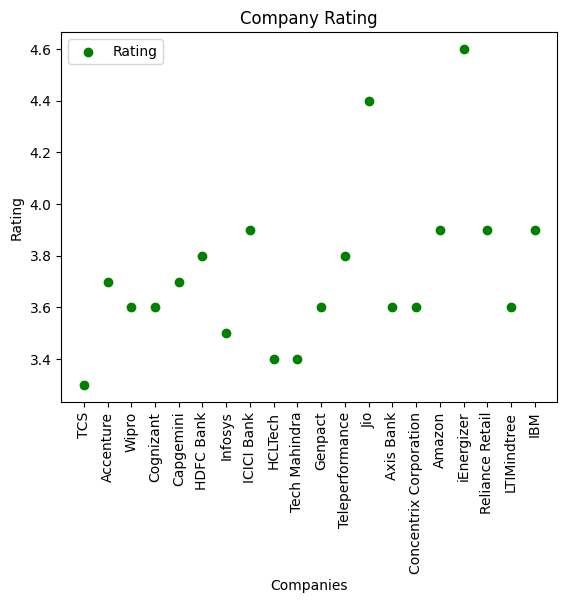

In [ ]:

# ============================================================================================================================

# ================================== || Data Analysis Using Graphs || ==================================

# ============================================================================================================================

# Here our whole data is inside teh dataframe variable

#Company Rating Graph'
plt.xlabel('Companies')
plt.xticks(rotation=90)
plt.ylabel('Rating')
plt.title('Company Rating')
plt.scatter(df['Name'], df['Rating'], color='green', label="Rating")
plt.legend()
plt.show()



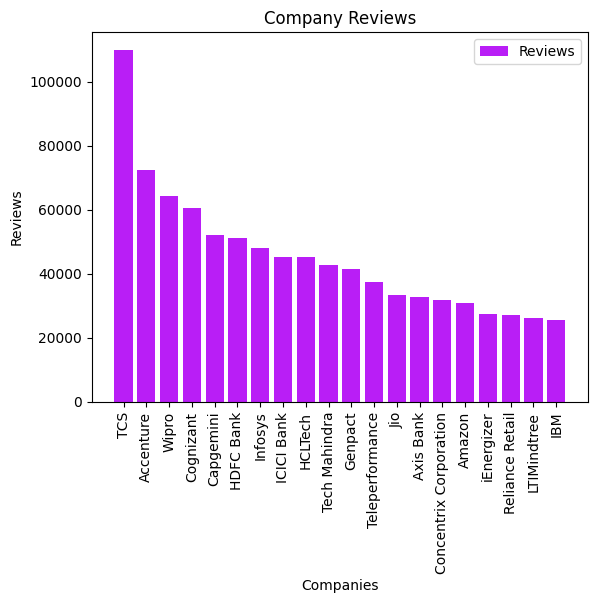

In [210]:
# Company Review Graph 
plt.xlabel('Companies')
plt.xticks(rotation=90)
plt.ylabel('Reviews')
plt.title('Company Reviews')
plt.bar(df['Name'], df['Reviews'], color='#b91ef6', label="Reviews")
plt.legend()
plt.show()


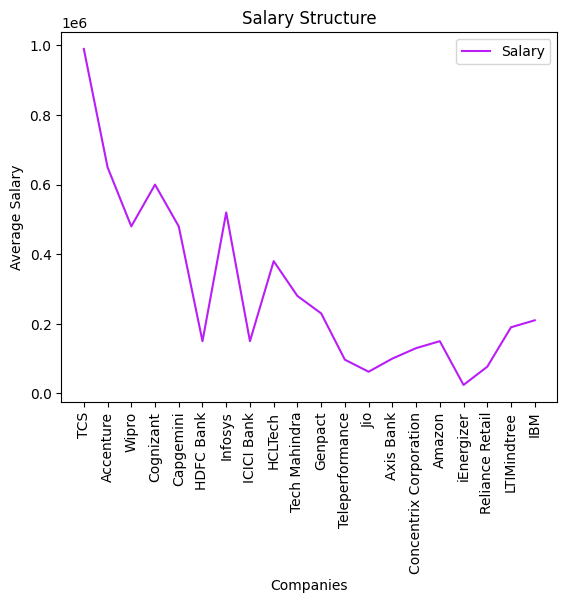

In [211]:

# Company salary Structure
plt.xlabel('Companies')
plt.xticks(rotation=90)
plt.ylabel('Average Salary')
plt.title('Salary Structure')
plt.plot(df['Name'], df['Salary'], color='#b91ef6', label="Salary")
plt.legend()
plt.show()


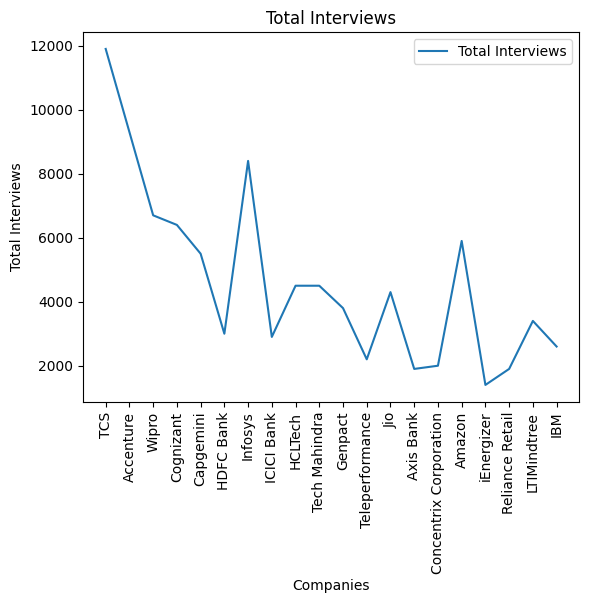

In [212]:

# Company Total Interviews Publish Graph 
plt.xlabel('Companies')
plt.xticks(rotation=90)
plt.ylabel('Total Interviews')
plt.title('Total Interviews')
plt.plot(df['Name'], df['Interviews'], label="Total Interviews")
plt.legend()
plt.show()

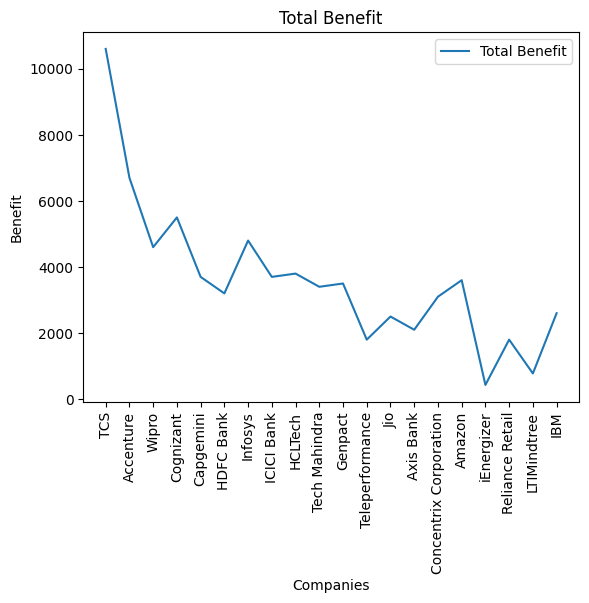

In [213]:
# Company Benefit Graph 
plt.xlabel('Companies')
plt.xticks(rotation=90)
plt.ylabel('Benefit')
plt.title('Total Benefit')
plt.plot(df['Name'], df['Benefit'], label="Total Benefit")
plt.legend()
plt.show()

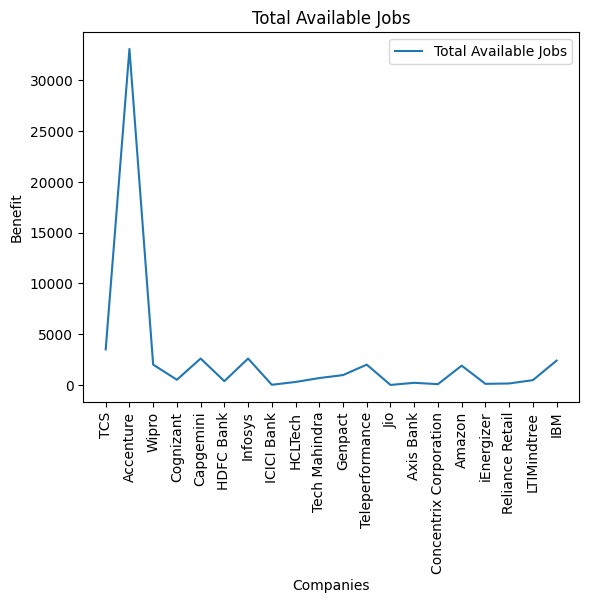

In [214]:
# Company Available Jobs
plt.xlabel('Companies')
plt.xticks(rotation=90)
plt.ylabel('Benefit')
plt.title('Total Available Jobs')
plt.plot(df['Name'], df['Available Jobs'], label="Total Available Jobs")
plt.legend()
plt.show()